In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import json
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.models import resnet18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)


class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv   = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.bn     = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(256, num_classes)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [ResidualBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = torch.relu(self.bn(self.conv(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

print('ResidualBlock and SmallResNet defined.')

ResidualBlock and SmallResNet defined.


In [3]:
# Augmentation as described in the paper: random crop + horizontal flip + normalize
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=128, shuffle=False, num_workers=2)
print(f'Train: {len(train_data)} | Test: {len(test_data)}')

100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


Train: 50000 | Test: 10000


In [4]:
def train_model(model, name, num_epochs=10):
    model = model.to(device)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n--- Training {name} | Params: {params:,} ---')

    criterion = nn.CrossEntropyLoss()
    # SGD + momentum + weight decay — same as paper
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    # LR schedule: drop at epoch 5 and 8
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5, 8], gamma=0.1)

    train_losses, train_accs, test_accs = [], [], []
    total_start = time.time()

    for epoch in range(num_epochs):
        t0 = time.time()
        model.train()
        total_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, pred = out.max(1)
            correct += pred.eq(y).sum().item()
            total   += y.size(0)

        train_acc = 100 * correct / total
        avg_loss  = total_loss / len(train_loader)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                _, pred = out.max(1)
                correct += pred.eq(y).sum().item()
                total   += y.size(0)

        test_acc = 100 * correct / total
        train_losses.append(avg_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        scheduler.step()

        print(f'Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.3f} | '
              f'Train: {train_acc:.1f}% | Test: {test_acc:.1f}% | '
              f'Time: {time.time()-t0:.1f}s')

    total_time = time.time() - total_start
    print(f'\n{name} done | Final Test Acc: {test_accs[-1]:.2f}% | Total: {total_time:.1f}s')

    return {
        'name':         name,
        'params':       params,
        'final_acc':    test_accs[-1],
        'total_time':   total_time,
        'train_losses': train_losses,
        'train_accs':   train_accs,
        'test_accs':    test_accs,
    }

print('train_model() defined.')

train_model() defined.


In [5]:
custom_model = SmallResNet(num_classes=10)
custom_results = train_model(custom_model, 'Custom SmallResNet')


--- Training Custom SmallResNet | Params: 2,777,674 ---
Epoch  1/10 | Loss: 1.695 | Train: 37.0% | Test: 48.3% | Time: 36.6s
Epoch  2/10 | Loss: 1.178 | Train: 57.4% | Test: 60.0% | Time: 36.0s
Epoch  3/10 | Loss: 0.921 | Train: 67.2% | Test: 61.8% | Time: 37.0s
Epoch  4/10 | Loss: 0.778 | Train: 72.5% | Test: 71.7% | Time: 35.9s
Epoch  5/10 | Loss: 0.656 | Train: 77.0% | Test: 77.4% | Time: 36.1s
Epoch  6/10 | Loss: 0.474 | Train: 83.5% | Test: 83.5% | Time: 36.1s
Epoch  7/10 | Loss: 0.431 | Train: 85.1% | Test: 84.3% | Time: 36.4s
Epoch  8/10 | Loss: 0.409 | Train: 85.7% | Test: 84.2% | Time: 36.8s
Epoch  9/10 | Loss: 0.379 | Train: 86.9% | Test: 84.8% | Time: 36.0s
Epoch 10/10 | Loss: 0.373 | Train: 87.2% | Test: 85.0% | Time: 36.2s

Custom SmallResNet done | Final Test Acc: 85.04% | Total: 363.1s


In [6]:
# weights=None means random initialization — same starting condition as custom model
official_model = resnet18(weights=None)
official_model.fc = nn.Linear(official_model.fc.in_features, 10)
official_results = train_model(official_model, 'Official ResNet-18')


--- Training Official ResNet-18 | Params: 11,181,642 ---
Epoch  1/10 | Loss: 2.113 | Train: 32.4% | Test: 45.5% | Time: 26.6s
Epoch  2/10 | Loss: 1.490 | Train: 46.1% | Test: 51.0% | Time: 26.5s
Epoch  3/10 | Loss: 1.303 | Train: 52.7% | Test: 58.8% | Time: 26.1s
Epoch  4/10 | Loss: 1.169 | Train: 58.3% | Test: 58.9% | Time: 25.8s
Epoch  5/10 | Loss: 1.055 | Train: 62.5% | Test: 66.3% | Time: 26.1s
Epoch  6/10 | Loss: 0.879 | Train: 68.8% | Test: 71.5% | Time: 26.3s
Epoch  7/10 | Loss: 0.835 | Train: 70.4% | Test: 72.3% | Time: 26.1s
Epoch  8/10 | Loss: 0.807 | Train: 71.4% | Test: 72.9% | Time: 27.2s
Epoch  9/10 | Loss: 0.775 | Train: 72.5% | Test: 73.4% | Time: 26.8s
Epoch 10/10 | Loss: 0.774 | Train: 72.6% | Test: 73.4% | Time: 26.6s

Official ResNet-18 done | Final Test Acc: 73.36% | Total: 264.0s


In [7]:
print('\n' + '='*55)
print(f'{"Model":<25} {"Params":>10} {"Test Acc":>10} {"Time":>8}')
print('='*55)
for r in [custom_results, official_results]:
    print(f'{r["name"]:<25} {r["params"]:>10,} {r["final_acc"]:>9.2f}% {r["total_time"]:>7.1f}s')
print('='*55)


Model                         Params   Test Acc     Time
Custom SmallResNet         2,777,674     85.04%   363.1s
Official ResNet-18        11,181,642     73.36%   264.0s


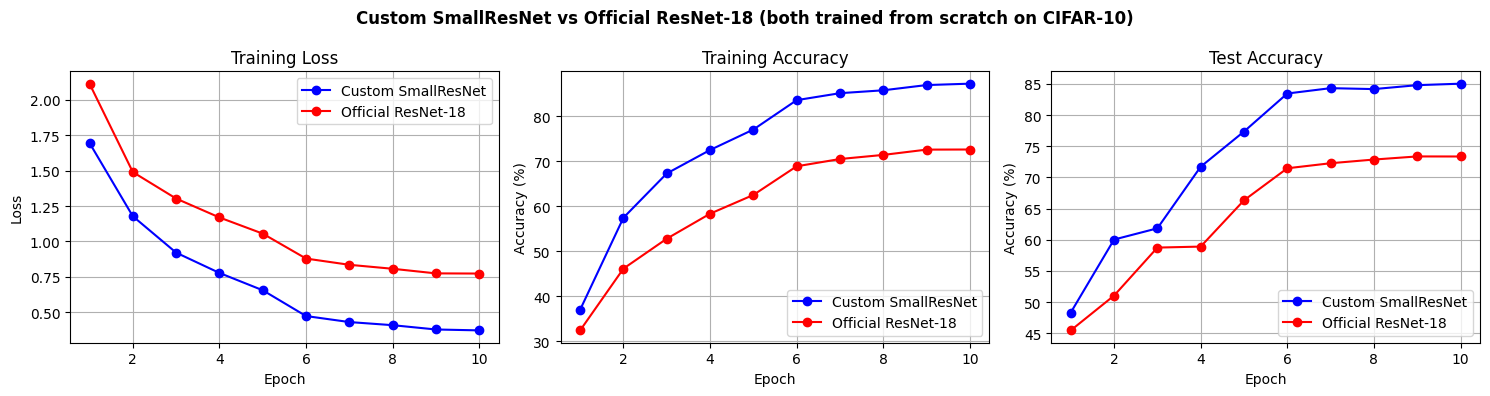

Saved: training_curves.png


In [8]:
epochs = list(range(1, len(custom_results['train_losses']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Custom SmallResNet vs Official ResNet-18 (both trained from scratch on CIFAR-10)',
             fontsize=12, fontweight='bold')

# --- Training Loss ---
axes[0].plot(epochs, custom_results['train_losses'],   'b-o', label='Custom SmallResNet')
axes[0].plot(epochs, official_results['train_losses'], 'r-o', label='Official ResNet-18')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Training Accuracy ---
axes[1].plot(epochs, custom_results['train_accs'],   'b-o', label='Custom SmallResNet')
axes[1].plot(epochs, official_results['train_accs'], 'r-o', label='Official ResNet-18')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

# --- Test Accuracy ---
axes[2].plot(epochs, custom_results['test_accs'],   'b-o', label='Custom SmallResNet')
axes[2].plot(epochs, official_results['test_accs'], 'r-o', label='Official ResNet-18')
axes[2].set_title('Test Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [9]:
# Save individual result files
with open('custom_results.txt', 'w') as f:
    f.write(f'Accuracy: {custom_results["final_acc"]:.2f}\n')
    f.write(f'Training Time: {custom_results["total_time"]:.2f}\n')
    f.write(f'Parameters: {custom_results["params"]}\n')

with open('custom_curves.json', 'w') as f:
    json.dump({
        'train_losses': custom_results['train_losses'],
        'train_accs':   custom_results['train_accs'],
        'test_accs':    custom_results['test_accs'],
    }, f)

with open('official_curves.json', 'w') as f:
    json.dump({
        'train_losses': official_results['train_losses'],
        'train_accs':   official_results['train_accs'],
        'test_accs':    official_results['test_accs'],
    }, f)

with open('final_results.txt', 'w') as f:
    f.write('=== CUSTOM SmallResNet (from scratch) ===\n')
    f.write(f'Accuracy: {custom_results["final_acc"]:.2f}%\n')
    f.write(f'Parameters: {custom_results["params"]:,}\n')
    f.write(f'Training Time: {custom_results["total_time"]:.2f}s\n')
    f.write('\n=== OFFICIAL ResNet-18 (from scratch) ===\n')
    f.write(f'Accuracy: {official_results["final_acc"]:.2f}%\n')
    f.write(f'Parameters: {official_results["params"]:,}\n')
    f.write(f'Training Time: {official_results["total_time"]:.2f}s\n')

# Save models
torch.save(custom_model.state_dict(), 'custom_model.pth')

print('All files saved:')
print('  custom_results.txt, custom_curves.json')
print('  official_curves.json, final_results.txt')
print('  custom_model.pth, training_curves.png')

All files saved:
  custom_results.txt, custom_curves.json
  official_curves.json, final_results.txt
  custom_model.pth, training_curves.png
